In [ ]:
!pip install -q tensorflow==2.20.0 keras==3.12.1 scikit-learn matplotlib seaborn pandas joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 862.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 95.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 144.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 142.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.2/225.2 kB 22.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os, json
warnings.filterwarnings('ignore')
np.random.seed(42)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, mean_absolute_percentage_error)
from sklearn.inspection import permutation_importance
import joblib

print(f"TensorFlow  : {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow  : 2.20.0
GPU available: False


## 1. Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH = "/content/drive/MyDrive/AcuVisor/synthetic_acoustics_dataset_v3.csv"
df = pd.read_csv(DATASET_PATH)

print(f"Loaded {len(df):,} rows x {df.shape[1]} columns")
print(f"Material combos : {df.groupby(['wall_mat','floor_mat','ceil_mat']).ngroups}")
print(f"Columns         : {list(df.columns)}")
print()
display(df.head(3))


Mounted at /content/drive
Loaded 16,000 rows x 25 columns
Material combos : 80
Columns         : ['L', 'W', 'H', 'volume_m3', 'src_x', 'src_y', 'src_z', 'mic_x', 'mic_y', 'mic_z', 'wall_mat', 'floor_mat', 'ceil_mat', 'wall_a', 'floor_a', 'ceil_a', 'panel_coverage', 'treated_wall_a', 'alpha_eff_before', 'alpha_eff_after', 'sabine_rt60_before', 'sabine_rt60_after', 'rt60_before', 'rt60_after', 'rt60_delta']



,L,W,H,volume_m3,src_x,src_y,src_z,mic_x,mic_y,mic_z,...,ceil_a,panel_coverage,treated_wall_a,alpha_eff_before,alpha_eff_after,sabine_rt60_before,sabine_rt60_after,rt60_before,rt60_after,rt60_delta
0,3.2033,5.1654,2.8809,47.6684,0.5267,4.5584,2.1830,0.9566,1.2450,1.4166,...,0.07,0.5311,0.5108,0.147328,0.408713,0.6406,0.2309,0.4303,0.2103,0.2199
1,4.0648,4.3119,2.7456,48.1219,2.3507,1.0411,1.5055,1.6522,2.0201,2.0209,...,0.07,0.2184,0.2513,0.152174,0.255057,0.6282,0.3748,0.3930,0.3288,0.0643
2,3.6989,4.2856,2.8739,45.5569,2.1279,1.0964,1.2764,3.0117,3.6216,2.1490,...,0.07,0.0348,0.0989,0.147628,0.164729,0.6403,0.5738,0.3722,0.3654,0.0068


## 2. Feature Set Definitions

Two feature sets are trained and compared


In [ ]:
# ── Feature sets ─────────────────────────────────────────────────────────
FEATURES_CORE = [
    "L", "W", "H",
    "wall_a", "floor_a", "ceil_a",
    "panel_coverage",
]  # 7 features

SPATIAL_COLS     = ["src_x", "src_y", "src_z", "mic_x", "mic_y", "mic_z"]
FEATURES_SPATIAL = FEATURES_CORE + SPATIAL_COLS   # 13 features

TARGET = "rt60_after"

df["combo_label"] = (df["wall_mat"] + "__" +
                      df["floor_mat"] + "__" +
                      df["ceil_mat"])
n_combos = df["combo_label"].nunique()

print(f"Core features    ({len(FEATURES_CORE):>2}): {FEATURES_CORE}")
print(f"Spatial features ({len(FEATURES_SPATIAL):>2}): {FEATURES_SPATIAL}")
print(f"Target                  : {TARGET}")
print(f"Distinct material combos: {n_combos}  (used as stratify key)")
print()
print("Target statistics:")
print(df[TARGET].describe().round(4))


Core features    ( 7): ['L', 'W', 'H', 'wall_a', 'floor_a', 'ceil_a', 'panel_coverage']
Spatial features (13): ['L', 'W', 'H', 'wall_a', 'floor_a', 'ceil_a', 'panel_coverage', 'src_x', 'src_y', 'src_z', 'mic_x', 'mic_y', 'mic_z']
Target                  : rt60_after
Distinct material combos: 80  (used as stratify key)

Target statistics:
count    16000.0000
mean         0.3425
std          0.1069
min          0.1004
25%          0.2578
50%          0.3361
75%          0.4209
max          0.6674
Name: rt60_after, dtype: float64


## 3. Train / Validation / Test Split



In [ ]:
y     = df[TARGET].values.astype(np.float32)
strat = df["combo_label"].values

X_core    = df[FEATURES_CORE].values.astype(np.float32)
X_spatial = df[FEATURES_SPATIAL].values.astype(np.float32)

# ── Stratified 70 / 15 / 15 split ────────────────────────────────────────
idx = np.arange(len(df))
idx_tr, idx_temp = train_test_split(idx, test_size=0.30,
                                    stratify=strat, random_state=42)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.50,
                                     stratify=strat[idx_temp], random_state=42)

def split_by_idx(X):
    return X[idx_tr], X[idx_val], X[idx_test]

Xc_tr,  Xc_val,  Xc_test  = split_by_idx(X_core)
Xs_tr,  Xs_val,  Xs_test  = split_by_idx(X_spatial)
y_train, y_val, y_test     = y[idx_tr], y[idx_val], y[idx_test]

print(f"Train : {len(idx_tr):>6,}  ({len(idx_tr)/len(df)*100:.1f}%)")
print(f"Val   : {len(idx_val):>6,}  ({len(idx_val)/len(df)*100:.1f}%)")
print(f"Test  : {len(idx_test):>6,}  ({len(idx_test)/len(df)*100:.1f}%)")
print()

# ── Confirm all 80 combos present in every partition ─────────────────────
for name, idxs in [("Train", idx_tr),("Val", idx_val),("Test", idx_test)]:
    n = df.iloc[idxs]["combo_label"].nunique()
    ok = "✓" if n == n_combos else "✗"
    print(f"  {name}: {n} combos {ok}")
print()

# ── Fit scalers on training data only ────────────────────────────────────
def make_scaler(Xtr, Xvl, Xtst):
    sc = StandardScaler()
    return sc, sc.fit_transform(Xtr), sc.transform(Xvl), sc.transform(Xtst)

sc_core,    Xc_tr_sc, Xc_val_sc, Xc_test_sc = make_scaler(Xc_tr, Xc_val, Xc_test)
sc_spatial, Xs_tr_sc, Xs_val_sc, Xs_test_sc = make_scaler(Xs_tr, Xs_val, Xs_test)
print("Scalers fitted.")


Train : 11,200  (70.0%)
Val   :  2,400  (15.0%)
Test  :  2,400  (15.0%)

  Train: 80 combos ✓
  Val: 80 combos ✓
  Test: 80 combos ✓

Scalers fitted.


## 4. Baseline: Sabine Formula

In [ ]:
def sabine_predict(X_raw):
    """Sabine RT60 from the 7 core features (position-agnostic)."""
    L, W, H = X_raw[:,0], X_raw[:,1], X_raw[:,2]
    wall_a, floor_a, ceil_a = X_raw[:,3], X_raw[:,4], X_raw[:,5]
    panel_cov = X_raw[:,6]
    PANEL_ALPHA = 0.90
    twa = np.clip(wall_a + panel_cov*(PANEL_ALPHA - wall_a), wall_a, 0.95)
    V   = L * W * H
    Sa  = 2*(L*H + W*H)*twa + L*W*floor_a + L*W*ceil_a
    return 0.161 * V / (Sa + 1e-9)

y_sabine = sabine_predict(Xc_test)
mae_s  = mean_absolute_error(y_test, y_sabine)
rmse_s = np.sqrt(mean_squared_error(y_test, y_sabine))
r2_s   = r2_score(y_test, y_sabine)
mape_s = mean_absolute_percentage_error(y_test, y_sabine) * 100
print(f"Sabine  MAE={mae_s:.4f}s  RMSE={rmse_s:.4f}s  R²={r2_s:.4f}  MAPE={mape_s:.2f}%")


Sabine  MAE=0.1357s  RMSE=0.3088s  R²=-7.1027  MAPE=33.31%


## 5. Feature Set Comparison: Core (7) vs Spatial (13)

Both models use **identical architecture and hyperparameters**.  
Only the input feature set differs.  
The winning model is fully evaluated in Sections 6–12.


In [ ]:
def build_mlp(input_dim, l2_reg=1e-4, dropout=0.2, lr=3e-4):

    # Surrogate acoustic MLP — 128 → BN → 64 → Dropout(0.2) → 32 → 1
    # Huber loss. Shared by Core and Spatial experiments.

    m = Sequential([
        Dense(128, activation='relu', kernel_regularizer=l2(l2_reg),
              input_shape=(input_dim,)),
        BatchNormalization(),
        Dense(64,  activation='relu', kernel_regularizer=l2(l2_reg)),
        Dropout(dropout),
        Dense(32,  activation='relu', kernel_regularizer=l2(l2_reg)),
        Dense(1,   activation='linear'),
    ], name="AcuVisor_MLP")
    m.compile(optimizer=Adam(learning_rate=lr), loss='huber', metrics=['mae'])
    return m

_CB = [
    EarlyStopping(monitor='val_mae', patience=20,
                  restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor='val_mae', factor=0.5,
                      patience=8, min_lr=1e-6, verbose=0),
]
model_A = build_mlp(Xc_tr_sc.shape[1])
model_A.summary()


Model: "AcuVisor_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,905 (46.50 KB)

 Trainable params: 11,649 (45.50 KB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
# ── Train Model A — Core (7 features) ────────────────────────────────────
print("Training Model A — Core (7 features)...")
hist_A = model_A.fit(Xc_tr_sc, y_train,
                     validation_data=(Xc_val_sc, y_val),
                     epochs=300, batch_size=64, callbacks=_CB, verbose=0)
ep_A = int(np.argmin(hist_A.history['val_mae'])) + 1
print(f"  Stopped at epoch {ep_A}   best val_mae = {min(hist_A.history['val_mae']):.4f}s")

# ── Train Model B — Spatial (13 features) ─────────────────────────────────
print("Training Model B — Spatial (13 features)...")
model_B = build_mlp(Xs_tr_sc.shape[1])
hist_B = model_B.fit(Xs_tr_sc, y_train,
                     validation_data=(Xs_val_sc, y_val),
                     epochs=300, batch_size=64, callbacks=_CB, verbose=0)
ep_B = int(np.argmin(hist_B.history['val_mae'])) + 1
print(f"  Stopped at epoch {ep_B}   best val_mae = {min(hist_B.history['val_mae']):.4f}s")
print()
print("Both models trained.")


Training Model A — Core (7 features)...
  Stopped at epoch 86   best val_mae = 0.0101s
Training Model B — Spatial (13 features)...
  Stopped at epoch 20   best val_mae = 0.0240s

Both models trained.


In [ ]:
# ── Evaluate both on the test set ─────────────────────────────────────────
def evaluate(model, X_sc, y_true):
    yp = model.predict(X_sc, verbose=0).flatten()
    return dict(
        MAE  = mean_absolute_error(y_true, yp),
        RMSE = np.sqrt(mean_squared_error(y_true, yp)),
        R2   = r2_score(y_true, yp),
        MAPE = mean_absolute_percentage_error(y_true, yp)*100,
        W50  = (np.abs(y_true-yp)<0.05).mean()*100,
        W100 = (np.abs(y_true-yp)<0.10).mean()*100,
    ), yp

res_A, yp_A = evaluate(model_A, Xc_test_sc, y_test)
res_B, yp_B = evaluate(model_B, Xs_test_sc, y_test)
res_S = dict(MAE=mae_s, RMSE=rmse_s, R2=r2_s, MAPE=mape_s,
             W50=(np.abs(y_test-y_sabine)<0.05).mean()*100,
             W100=(np.abs(y_test-y_sabine)<0.10).mean()*100)

cmp = pd.DataFrame({
    "Sabine (baseline)"    : res_S,
    "Model A  Core (7)"    : res_A,
    "Model B  Spatial (13)": res_B,
}).T.rename(columns={"W50":"Within50ms%","W100":"Within100ms%"}).round(4)
cmp.index.name = "Model"

print("=" * 62)
print("FEATURE SET COMPARISON  —  TEST SET")
print("=" * 62)
display(cmp)
print()

# ── Select winner ─────────────────────────────────────────────────────────
if res_B["MAE"] < res_A["MAE"]:
    pct = (res_A["MAE"]-res_B["MAE"])/res_A["MAE"]*100
    print(f"Model B (Spatial) wins  —  {pct:.1f}% lower MAE than Core.")
    print(   "   -> Update ml_service.py: pass src/mic positions.")
    WINNER_MODEL  = model_B;  WINNER_SC    = sc_spatial
    WINNER_X_TEST = Xs_test_sc; WINNER_X_TR = Xs_tr_sc
    WINNER_FEATURES = FEATURES_SPATIAL
    winner_name, winner_res, winner_pred, winner_hist = "Spatial (13)", res_B, yp_B, hist_B
else:
    pct = (res_B["MAE"]-res_A["MAE"])/res_B["MAE"]*100 if res_B["MAE"]>0 else 0
    print(f"Model A (Core) wins — {pct:.1f}% lower MAE than Spatial.")
    print(   "   -> Keep current ml_service.py unchanged.")
    WINNER_MODEL  = model_A;  WINNER_SC    = sc_core
    WINNER_X_TEST = Xc_test_sc; WINNER_X_TR = Xc_tr_sc
    WINNER_FEATURES = FEATURES_CORE
    winner_name, winner_res, winner_pred, winner_hist = "Core (7)", res_A, yp_A, hist_A


FEATURE SET COMPARISON  —  TEST SET


,MAE,RMSE,R2,MAPE,Within50ms%,Within100ms%
Model,,,,,,
Sabine (baseline),0.1357,0.3088,-7.1027,33.3069,61.8333,73.0417
Model A Core (7),0.0099,0.0126,0.9866,3.2416,99.8750,100.0000
Model B Spatial (13),0.1462,0.1723,-1.5234,42.5765,16.5000,35.4167



Model A (Core) wins — 93.3% lower MAE than Spatial.
   -> Keep current ml_service.py unchanged.


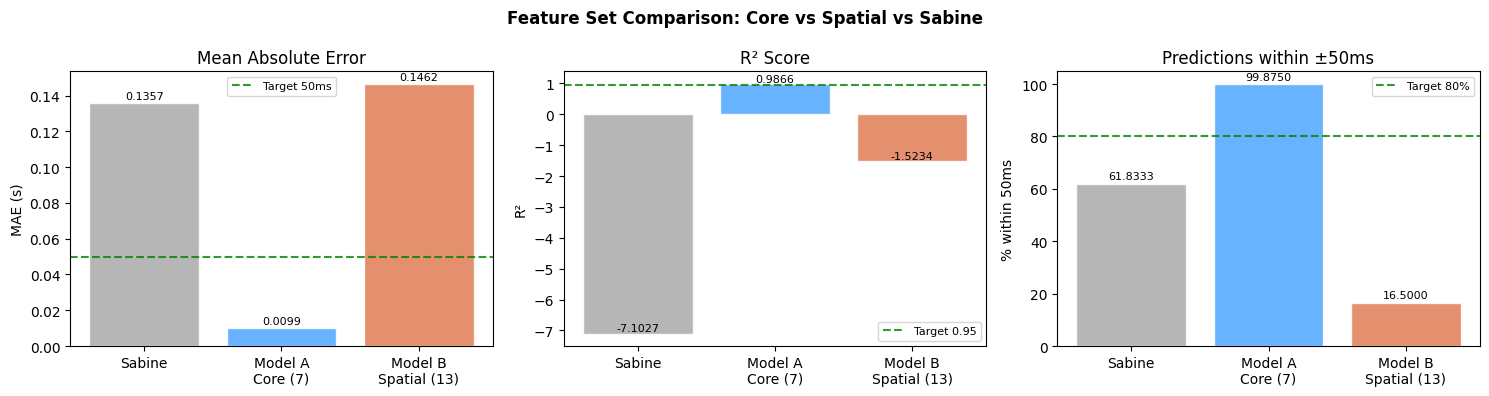

Winner: Core (7)  |  MAE=0.0099s  |  R²=0.9866


In [ ]:
# ── Comparison bar chart ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Feature Set Comparison: Core vs Spatial vs Sabine",
             fontsize=12, fontweight='bold')

bar_labels = ["Sabine", "Model A\nCore (7)", "Model B\nSpatial (13)"]
bar_colors = ["#AAAAAA", "#4DA6FF", "#E07B54"]

specs = [
    (axes[0], [res_S["MAE"], res_A["MAE"], res_B["MAE"]],
     "MAE (s)", "Mean Absolute Error",     0.05, "Target 50ms"),
    (axes[1], [res_S["R2"],  res_A["R2"],  res_B["R2"]],
     "R²",      "R² Score",                0.95, "Target 0.95"),
    (axes[2], [res_S["W50"], res_A["W50"], res_B["W50"]],
     "% within 50ms", "Predictions within ±50ms", 80, "Target 80%"),
]
for ax, vals, ylabel, title, hline, hl in specs:
    bars = ax.bar(bar_labels, vals, color=bar_colors, alpha=0.85, edgecolor='white')
    ax.axhline(hline, color='green', linestyle='--', alpha=0.8, label=hl)
    ax.set_title(title); ax.set_ylabel(ylabel); ax.legend(fontsize=8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height() + max(vals)*0.01 + 1e-9,
                f"{v:.4f}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig("feature_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Winner: {winner_name}  |  MAE={winner_res['MAE']:.4f}s  |  R²={winner_res['R2']:.4f}")


### 6. Training Dynamics (Winning Model)

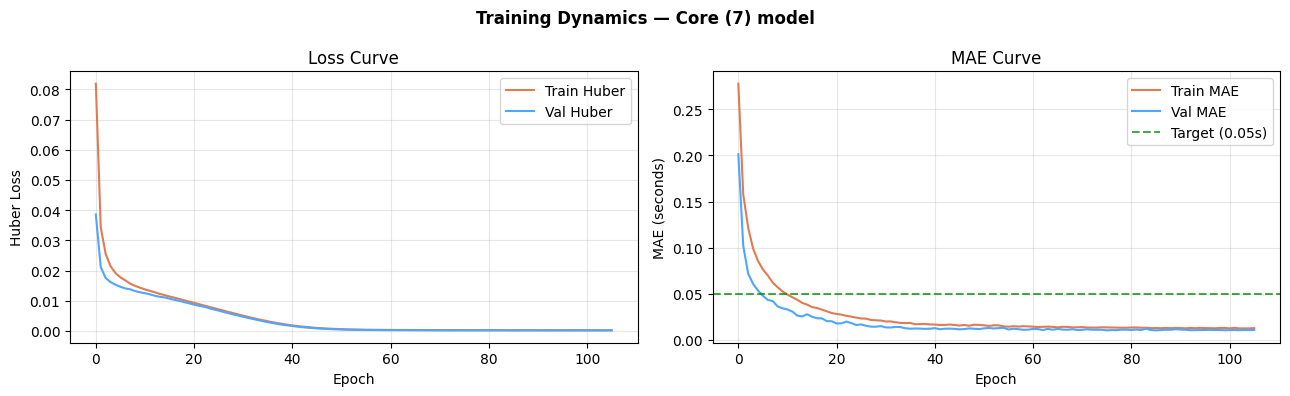

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f"Training Dynamics — {winner_name} model",
             fontsize=12, fontweight='bold')

axes[0].plot(winner_hist.history['loss'],     label='Train Huber', color='#E07B54')
axes[0].plot(winner_hist.history['val_loss'], label='Val Huber',   color='#4DA6FF')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Huber Loss")
axes[0].set_title("Loss Curve"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(winner_hist.history['mae'],     label='Train MAE', color='#E07B54')
axes[1].plot(winner_hist.history['val_mae'], label='Val MAE',   color='#4DA6FF')
axes[1].axhline(0.05, color='green', linestyle='--', alpha=0.7, label='Target (0.05s)')
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE (seconds)")
axes[1].set_title("MAE Curve"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches='tight')
plt.show()


## 7. Full Evaluation — Winning Model

In [ ]:
# Use the winning model and its test predictions
y_pred    = winner_pred
residuals = y_test - y_pred
mae   = winner_res["MAE"];  rmse  = winner_res["RMSE"]
r2    = winner_res["R2"];   mape  = winner_res["MAPE"]
within_50ms  = winner_res["W50"]
within_100ms = winner_res["W100"]
within_10pct = (np.abs(residuals)/y_test < 0.10).mean() * 100

print("=" * 55)
print(f"FULL EVALUATION  —  {winner_name}")
print("=" * 55)
for k, v, target, direction in [
    ("MAE (s)",         mae,   0.05, "<"),
    ("RMSE (s)",        rmse,  None, None),
    ("R²",             r2,    0.95, ">"),
    ("MAPE (%)",        mape,  None, None),
    ("Within ±50ms (%)",within_50ms,  80, ">"),
    ("Within ±100ms (%)",within_100ms, 90, ">"),
]:
    flag = ""
    if target is not None:
        flag = " ✓" if (direction=="<" and v<target) or (direction==">" and v>target) else " ✗"
    print(f"  {k:<22}: {v:>8.4f}{flag}")
print()
print(f"vs Sabine baseline:")
print(f"  Sabine MAE : {mae_s:.4f}s  ->  improvement: {(mae_s-mae)/mae_s*100:.1f}%")
print(f"  Sabine R²  : {r2_s:.4f}   ->  improvement: {r2-r2_s:.4f}")


FULL EVALUATION  —  Core (7)
  MAE (s)               :   0.0099 ✓
  RMSE (s)              :   0.0126
  R²                    :   0.9866 ✓
  MAPE (%)              :   3.2416
  Within ±50ms (%)      :  99.8750 ✓
  Within ±100ms (%)     : 100.0000 ✓

vs Sabine baseline:
  Sabine MAE : 0.1357s  ->  improvement: 92.7%
  Sabine R²  : -7.1027   ->  improvement: 8.0893


### Diagnostic plots

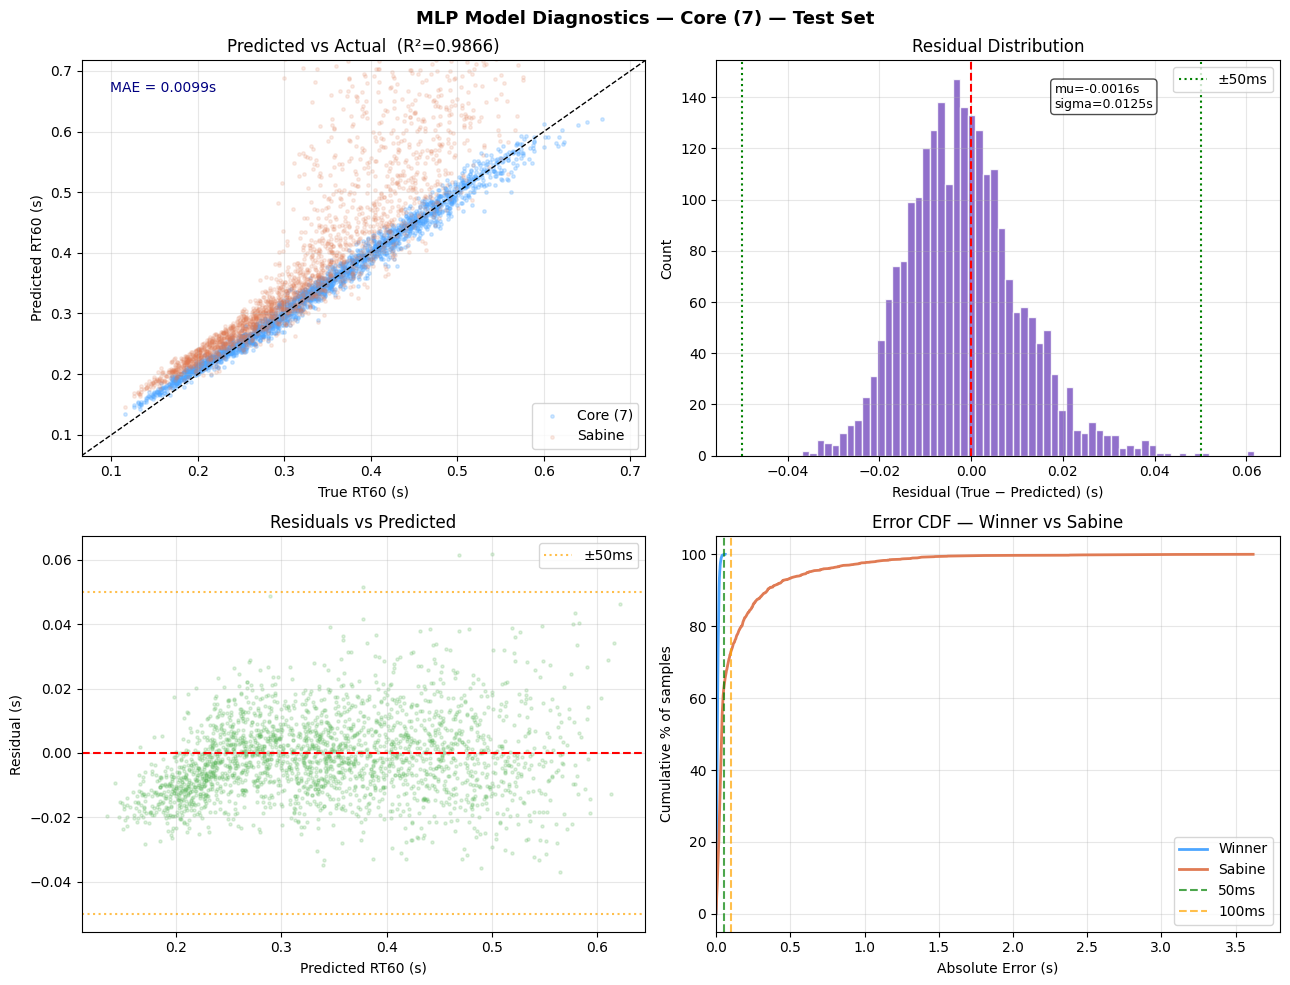

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle(f"MLP Model Diagnostics — {winner_name} — Test Set",
             fontsize=13, fontweight='bold')

lims = [min(y_test.min(), y_pred.min()) - 0.05,
        max(y_test.max(), y_pred.max()) + 0.05]

ax = axes[0, 0]
ax.scatter(y_test, y_pred,    alpha=0.25, s=6, color='#4DA6FF', label=winner_name)
ax.scatter(y_test, y_sabine, alpha=0.15, s=6, color='#E07B54', label='Sabine')
ax.plot(lims, lims, 'k--', linewidth=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("True RT60 (s)"); ax.set_ylabel("Predicted RT60 (s)")
ax.set_title(f"Predicted vs Actual  (R²={r2:.4f})")
ax.legend(); ax.grid(True, alpha=0.3)
ax.text(0.05, 0.92, f"MAE = {mae:.4f}s", transform=ax.transAxes, fontsize=10, color='navy')

ax = axes[0, 1]
ax.hist(residuals, bins=60, color='#7E57C2', alpha=0.85, edgecolor='white')
ax.axvline(0, color='red', linestyle='--')
ax.axvline( 0.05, color='green', linestyle=':', label='±50ms')
ax.axvline(-0.05, color='green', linestyle=':')
ax.set_xlabel("Residual (True − Predicted) (s)"); ax.set_ylabel("Count")
ax.set_title("Residual Distribution"); ax.legend(); ax.grid(True, alpha=0.3)
ax.text(0.60, 0.88, f"mu={residuals.mean():.4f}s\nsigma={residuals.std():.4f}s",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', fc='white', alpha=0.7))

ax = axes[1, 0]
ax.scatter(y_pred, residuals, alpha=0.2, s=5, color='#5CB85C')
ax.axhline(0, color='red', linestyle='--')
ax.axhline( 0.05, color='orange', linestyle=':', alpha=0.7, label='±50ms')
ax.axhline(-0.05, color='orange', linestyle=':', alpha=0.7)
ax.set_xlabel("Predicted RT60 (s)"); ax.set_ylabel("Residual (s)")
ax.set_title("Residuals vs Predicted"); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
for errs, lbl, col in [(np.abs(residuals),"Winner","#4DA6FF"),
                        (np.abs(y_test-y_sabine),"Sabine","#E07B54")]:
    sx = np.sort(errs)
    ax.plot(sx, np.arange(1,len(sx)+1)/len(sx)*100, color=col, label=lbl, linewidth=2)
ax.axvline(0.05, color='green', linestyle='--', alpha=0.7, label='50ms')
ax.axvline(0.10, color='orange', linestyle='--', alpha=0.7, label='100ms')
ax.set_xlabel("Absolute Error (s)"); ax.set_ylabel("Cumulative % of samples")
ax.set_title("Error CDF — Winner vs Sabine"); ax.legend(); ax.grid(True, alpha=0.3)
ax.set_xlim(left=0)

plt.tight_layout()
plt.savefig("model_diagnostics.png", dpi=150, bbox_inches='tight')
plt.show()


## 8. Error Breakdown by Material Combination

In [ ]:
# ── Attach winning model predictions to test rows ────────────────────────
# Use the same stratified idx_test from the split cell above.
df_test_eval = df.iloc[idx_test].copy().reset_index(drop=True)
df_test_eval["y_true"]  = y_test
df_test_eval["y_pred"]  = winner_pred
df_test_eval["abs_err"] = np.abs(y_test - winner_pred)
df_test_eval["rel_err"] = df_test_eval["abs_err"] / df_test_eval["y_true"]

# ── Per-wall-material breakdown ───────────────────────────────────────────
wall_bd = df_test_eval.groupby("wall_mat").agg(
    N=("abs_err","count"),
    MAE=("abs_err","mean"),
    RMSE=("abs_err", lambda x: np.sqrt((x**2).mean())),
    Within_50ms=("abs_err", lambda x: (x<0.05).mean()*100),
    Mean_RT60=("y_true","mean"),
).round(4).reset_index()
wall_bd.columns = ["Wall mat","N","MAE (s)","RMSE (s)","Within 50ms (%)","Mean RT60 (s)"]
print("Error by WALL material:")
display(wall_bd)
print()

# ── Per-floor-material breakdown ──────────────────────────────────────────
floor_bd = df_test_eval.groupby("floor_mat").agg(
    N=("abs_err","count"),
    MAE=("abs_err","mean"),
    RMSE=("abs_err", lambda x: np.sqrt((x**2).mean())),
    Within_50ms=("abs_err", lambda x: (x<0.05).mean()*100),
).round(4).reset_index()
floor_bd.columns = ["Floor mat","N","MAE (s)","RMSE (s)","Within 50ms (%)"]
print("Error by FLOOR material:")
display(floor_bd)


Error by WALL material:


,Wall mat,N,MAE (s),RMSE (s),Within 50ms (%),Mean RT60 (s)
0,brick,480,0.0091,0.0118,99.7917,0.3526
1,concrete,480,0.0103,0.0136,99.5833,0.3488
2,glass,480,0.0104,0.0131,100.0000,0.3444
3,painted_plaster,480,0.0092,0.0115,100.0000,0.3396
4,wood_panel,480,0.0104,0.0127,100.0000,0.3169



Error by FLOOR material:


,Floor mat,N,MAE (s),RMSE (s),Within 50ms (%)
0,carpet,600,0.0100,0.0122,100.0000
1,concrete_floor,600,0.0102,0.0131,99.8333
2,tile,600,0.0096,0.0127,99.8333
3,wood_floor,600,0.0096,0.0123,99.8333


Error by panel coverage band:


,coverage_band,N,MAE,RMSE,Within_50ms,RT60_before_mean
0,0–10%,304,0.0121,0.0159,99.3421,0.4658
1,10–25%,480,0.0103,0.0133,99.7917,0.4579
2,25–50%,784,0.0085,0.0110,100.0000,0.4595
3,50–75%,832,0.0100,0.0122,100.0000,0.4601


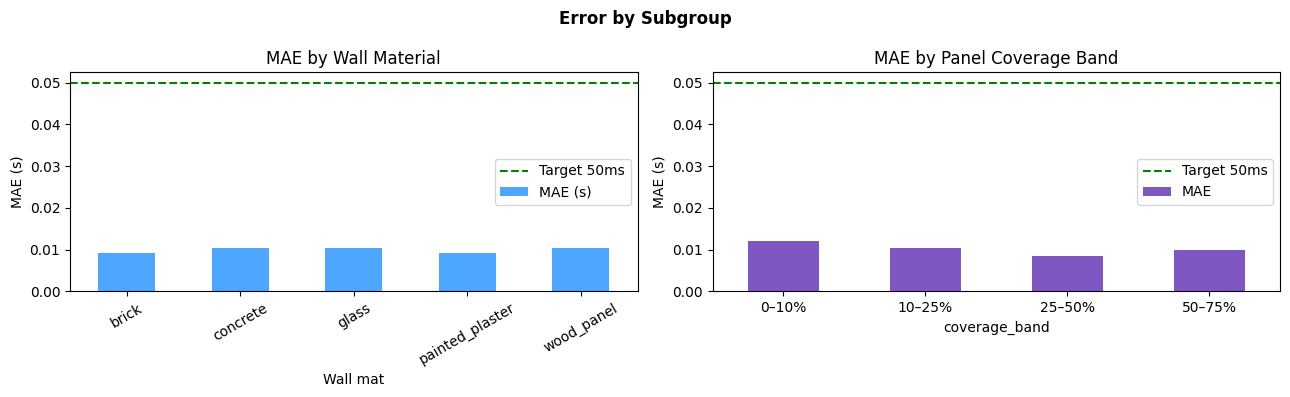

In [ ]:
# ── Error by panel coverage band ─────────────────────────────────────────
bins   = [-0.01, 0.10, 0.25, 0.50, 0.75, 1.0]
labels = ["0–10%","10–25%","25–50%","50–75%","75%+"]
df_test_eval["coverage_band"] = pd.cut(
    df_test_eval["panel_coverage"], bins=bins, labels=labels)

cov_breakdown = df_test_eval.groupby("coverage_band", observed=True).agg(
    N        = ("abs_err", "count"),
    MAE      = ("abs_err", "mean"),
    RMSE     = ("abs_err", lambda x: np.sqrt((x**2).mean())),
    Within_50ms = ("abs_err", lambda x: (x<0.05).mean()*100),
    RT60_before_mean = ("rt60_before", "mean"),
).round(4).reset_index()
print("Error by panel coverage band:")
display(cov_breakdown)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Error by Subgroup", fontsize=12, fontweight='bold')

wall_bd.plot(x="Wall mat", y="MAE (s)", kind="bar", ax=axes[0],
             color='#4DA6FF', legend=False)
axes[0].axhline(0.05, color='green', linestyle='--', label='Target 50ms')
axes[0].set_title("MAE by Wall Material"); axes[0].set_ylabel("MAE (s)")
axes[0].tick_params(axis='x', rotation=30); axes[0].legend()

cov_breakdown.plot(x="coverage_band", y="MAE", kind="bar", ax=axes[1],
                   color='#7E57C2', legend=False)
axes[1].axhline(0.05, color='green', linestyle='--', label='Target 50ms')
axes[1].set_title("MAE by Panel Coverage Band"); axes[1].set_ylabel("MAE (s)")
axes[1].tick_params(axis='x', rotation=0); axes[1].legend()

plt.tight_layout()
plt.savefig("error_by_subgroup.png", dpi=150, bbox_inches='tight')
plt.show()

## 9. 5-Fold Cross-Validation
Cross-validation confirms the model generalises and is not overfit to the  
particular train/test split.

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results     = []
fold_histories = []

X_all_winner = df[WINNER_FEATURES].values.astype(np.float32)
y_all         = df[TARGET].values.astype(np.float32)

print(f"Running 5-fold CV on winner feature set: {WINNER_FEATURES}")

for fold, (tr_idx, vl_idx) in enumerate(kf.split(X_all_winner), 1):
    print(f"  Fold {fold}/5 ...", end=" ")
    Xtr, Xvl = X_all_winner[tr_idx], X_all_winner[vl_idx]
    ytr, yvl = y_all[tr_idx], y_all[vl_idx]

    sc = StandardScaler()
    Xtr_sc, Xvl_sc = sc.fit_transform(Xtr), sc.transform(Xvl)

    m = build_mlp(Xtr_sc.shape[1])
    h = m.fit(Xtr_sc, ytr, validation_data=(Xvl_sc, yvl),
              epochs=200, batch_size=64,
              callbacks=[EarlyStopping(monitor='val_mae', patience=15,
                                       restore_best_weights=True)],
              verbose=0)
    fold_histories.append(h.history['val_mae'])

    yp  = m.predict(Xvl_sc, verbose=0).flatten()
    mae_f  = mean_absolute_error(yvl, yp)
    rmse_f = np.sqrt(mean_squared_error(yvl, yp))
    r2_f   = r2_score(yvl, yp)
    w50    = (np.abs(yvl - yp) < 0.05).mean() * 100
    cv_results.append({"Fold":fold,"MAE":mae_f,"RMSE":rmse_f,"R²":r2_f,"Within50ms%":w50})
    print(f"MAE={mae_f:.4f}s  R²={r2_f:.4f}  W50={w50:.1f}%")

cv_df = pd.DataFrame(cv_results)
print("\n" + "="*55)
print("5-FOLD CROSS-VALIDATION SUMMARY")
print("="*55)
display(cv_df)
print("\nMean +/- Std:")
for col in ["MAE","RMSE","R²","Within50ms%"]:
    print(f"  {col:<15}: {cv_df[col].mean():.4f} +/- {cv_df[col].std():.4f}")


Running 5-fold CV on winner feature set: ['L', 'W', 'H', 'wall_a', 'floor_a', 'ceil_a', 'panel_coverage']
  Fold 1/5 ... MAE=0.0098s  R²=0.9856  W50=99.8%
  Fold 2/5 ... MAE=0.0096s  R²=0.9858  W50=99.8%
  Fold 3/5 ... MAE=0.0112s  R²=0.9809  W50=99.4%
  Fold 4/5 ... MAE=0.0128s  R²=0.9732  W50=98.2%
  Fold 5/5 ... MAE=0.0100s  R²=0.9843  W50=99.5%

5-FOLD CROSS-VALIDATION SUMMARY


,Fold,MAE,RMSE,R²,Within50ms%
0,1,0.009785,0.012840,0.985569,99.75000
1,2,0.009625,0.012857,0.985769,99.78125
2,3,0.011203,0.014568,0.980914,99.37500
3,4,0.012762,0.017561,0.973187,98.25000
4,5,0.009992,0.013433,0.984263,99.53125



Mean +/- Std:
  MAE            : 0.0107 +/- 0.0013
  RMSE           : 0.0143 +/- 0.0020
  R²             : 0.9819 +/- 0.0053
  Within50ms%    : 99.3375 +/- 0.6302


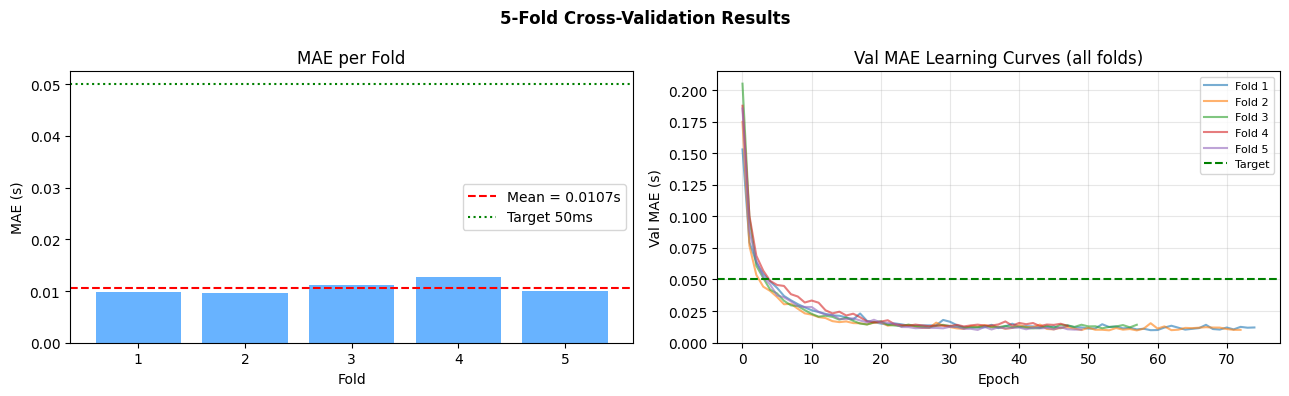

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("5-Fold Cross-Validation Results", fontsize=12, fontweight='bold')

# Bar chart of fold MAEs
axes[0].bar(cv_df["Fold"], cv_df["MAE"], color='#4DA6FF', alpha=0.85)
axes[0].axhline(cv_df["MAE"].mean(), color='red', linestyle='--',
                label=f"Mean = {cv_df['MAE'].mean():.4f}s")
axes[0].axhline(0.05, color='green', linestyle=':', label='Target 50ms')
axes[0].set_xlabel("Fold"); axes[0].set_ylabel("MAE (s)")
axes[0].set_title("MAE per Fold"); axes[0].legend(); axes[0].set_ylim(bottom=0)

# Val MAE learning curves across folds
for i, hist in enumerate(fold_histories, 1):
    axes[1].plot(hist, alpha=0.6, label=f"Fold {i}")
axes[1].axhline(0.05, color='green', linestyle='--', label='Target')
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val MAE (s)")
axes[1].set_title("Val MAE Learning Curves (all folds)")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cv_results.png", dpi=150, bbox_inches='tight')
plt.show()

## 10. Feature Importance (Permutation Method)

,Feature,Importance,Std
0,panel_coverage,0.08731,0.00125
1,L,0.04252,0.00056
2,floor_a,0.02551,0.00062
3,W,0.02183,0.00049
4,wall_a,0.00685,0.00021
5,ceil_a,0.00444,0.00015
6,H,0.00203,0.00011


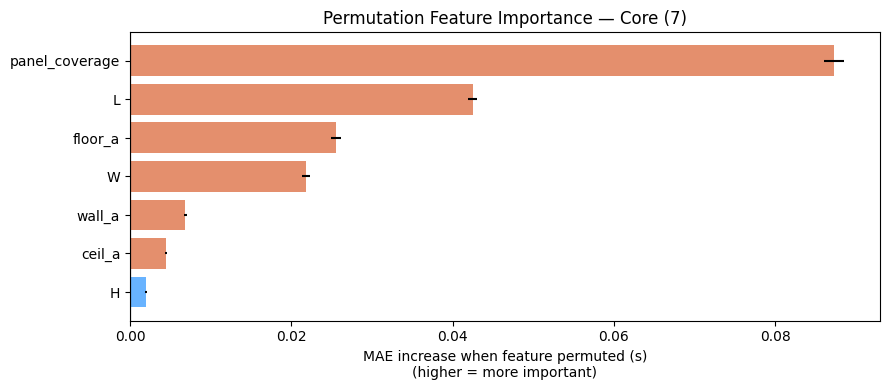

In [ ]:
from sklearn.base import BaseEstimator, RegressorMixin

class KerasWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, keras_model, scaler):
        self.keras_model = keras_model; self.scaler = scaler
    def fit(self, X, y): return self
    def predict(self, X):
        return self.keras_model.predict(
            self.scaler.transform(X), verbose=0).flatten()

wrapper = KerasWrapper(WINNER_MODEL, WINNER_SC)
perm = permutation_importance(wrapper, df[WINNER_FEATURES].values.astype(np.float32)[idx_test],
                               y_test, n_repeats=20, random_state=42,
                               scoring='neg_mean_absolute_error')

imp_df = pd.DataFrame({
    "Feature":   WINNER_FEATURES,
    "Importance": perm.importances_mean,
    "Std":        perm.importances_std,
}).sort_values("Importance", ascending=False).reset_index(drop=True)

display(imp_df.round(5))

colors = ['#E07B54' if v > 0.003 else '#4DA6FF' for v in imp_df["Importance"]]
plt.figure(figsize=(9, max(4, len(WINNER_FEATURES)*0.4)))
plt.barh(imp_df["Feature"][::-1], imp_df["Importance"][::-1],
         xerr=imp_df["Std"][::-1], color=colors[::-1], alpha=0.85)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel("MAE increase when feature permuted (s)\n(higher = more important)")
plt.title(f"Permutation Feature Importance — {winner_name}")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()


## 11. Inference Speed Test

In [ ]:
import time

x_single = WINNER_SC.transform(df[WINNER_FEATURES].values[:1].astype(np.float32))
_ = WINNER_MODEL.predict(x_single, verbose=0)   # warm-up

N_TRIALS = 500
times = []
for _ in range(N_TRIALS):
    t0 = time.perf_counter()
    _ = WINNER_MODEL.predict(x_single, verbose=0)
    times.append((time.perf_counter()-t0)*1000)

times_arr = np.array(times)
print(f"Single-sample inference — {winner_name} model:")
print(f"  Mean   : {times_arr.mean():.3f} ms")
print(f"  Median : {np.median(times_arr):.3f} ms")
print(f"  P95    : {np.percentile(times_arr,95):.3f} ms")
print()
est = times_arr.mean() * 1200 / 1000
print(f"Estimated GA inference (40 pop x 30 gen): {est:.2f}s")
if times_arr.mean() < 5.0:
    print("✓  Inference speed acceptable for real-time use.")
else:
    print("⚠  Consider TFLite export.")


Single-sample inference — Core (7) model:
  Mean   : 46.965 ms
  Median : 46.557 ms
  P95    : 50.145 ms

Estimated GA inference (40 pop x 30 gen): 56.36s
⚠  Consider TFLite export.


## 12. Final Results Summary

In [ ]:
print("=" * 62)
print("  AcuVisor MLP — FINAL EVALUATION SUMMARY  (v3)")
print("=" * 62)
print(f"  Dataset             : {len(df):,} rows, {n_combos} material combos")
print(f"  Winner model        : {winner_name}")
print(f"  Features ({len(WINNER_FEATURES):>2})         : {WINNER_FEATURES}")
print(f"  Architecture        : 128-BN-64-Drop(0.2)-32-1  (Huber loss)")
print()
print("  -- Feature Set Comparison (test set) ----------------")
print(f"  Sabine MAE    : {mae_s:.4f}s  R²={r2_s:.4f}")
print(f"  Model A Core  : {res_A['MAE']:.4f}s  R²={res_A['R2']:.4f}")
print(f"  Model B Spat  : {res_B['MAE']:.4f}s  R²={res_B['R2']:.4f}")
print(f"  Winner        : {winner_name}")
print()
print("  -- Winning Model (test set) --------------------------")
print(f"  MAE           : {mae:.4f}s {'✓' if mae<0.05 else '✗'}")
print(f"  RMSE          : {rmse:.4f}s")
print(f"  R²            : {r2:.4f}  {'✓' if r2>0.95 else '✗'}")
print(f"  MAPE          : {mape:.2f}%")
print(f"  Within +-50ms : {within_50ms:.1f}%  {'✓' if within_50ms>80 else '✗'}")
print(f"  vs Sabine     : {(mae_s-mae)/mae_s*100:.1f}% better MAE")
print()
print("  -- 5-Fold CV -----------------------------------------")
print(f"  Mean MAE      : {cv_df['MAE'].mean():.4f} +/- {cv_df['MAE'].std():.4f}s")
print(f"  Mean R²       : {cv_df['R²'].mean():.4f} +/- {cv_df['R²'].std():.4f}")
print()
print("=" * 62)


  AcuVisor MLP — FINAL EVALUATION SUMMARY  (v3)
  Dataset             : 16,000 rows, 80 material combos
  Winner model        : Core (7)
  Features ( 7)         : ['L', 'W', 'H', 'wall_a', 'floor_a', 'ceil_a', 'panel_coverage']
  Architecture        : 128-BN-64-Drop(0.2)-32-1  (Huber loss)

  -- Feature Set Comparison (test set) ----------------
  Sabine MAE    : 0.1357s  R²=-7.1027
  Model A Core  : 0.0099s  R²=0.9866
  Model B Spat  : 0.1462s  R²=-1.5234
  Winner        : Core (7)

  -- Winning Model (test set) --------------------------
  MAE           : 0.0099s ✓
  RMSE          : 0.0126s
  R²            : 0.9866  ✓
  MAPE          : 3.24%
  Within +-50ms : 99.9%  ✓
  vs Sabine     : 92.7% better MAE

  -- 5-Fold CV -----------------------------------------
  Mean MAE      : 0.0107 +/- 0.0013s
  Mean R²       : 0.9819 +/- 0.0053



## 13. Save Model Artefacts

In [ ]:
SAVE_DIR = "/content/drive/MyDrive/AcuVisor"
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Save Keras model ──────────────────────────────────────────────────────
model_path  = os.path.join(SAVE_DIR, "mlp_rt60_model_v3.keras")
scaler_path = os.path.join(SAVE_DIR, "feature_scaler_v3.pkl")

WINNER_MODEL.save(model_path)
joblib.dump(WINNER_SC, scaler_path)

# ── Save evaluation JSON ──────────────────────────────────────────────────
eval_out = {
    "winner_model"     : winner_name,
    "winner_features"  : WINNER_FEATURES,
    "dataset_size"     : int(len(df)),
    "material_combos"  : int(n_combos),
    "architecture"     : "128-BN-64-Dropout(0.2)-32-1  Huber loss",
    "feature_comparison": {
        "sabine" : {k: round(float(v),4) for k,v in res_S.items()},
        "core_7" : {k: round(float(v),4) for k,v in res_A.items()},
        "spatial_13": {k: round(float(v),4) for k,v in res_B.items()},
    },
    "test_set_metrics" : {k: round(float(v),4) for k,v in winner_res.items()},
    "cv_5fold"         : {
        "mean_MAE": round(float(cv_df['MAE'].mean()), 4),
        "std_MAE" : round(float(cv_df['MAE'].std()),  4),
        "mean_R2" : round(float(cv_df['R²'].mean()),  4),
        "std_R2"  : round(float(cv_df['R²'].std()),   4),
    },
}
results_path = os.path.join(SAVE_DIR, "eval_results_v3.json")
with open(results_path, 'w') as f:
    json.dump(eval_out, f, indent=2)

print(f"Saved:")
print(f"  Model   : {model_path}")
print(f"  Scaler  : {scaler_path}")
print(f"  Results : {results_path}")

## 14. Load & Verify (end-to-end check)

In [ ]:
from tensorflow.keras.models import load_model as lm
import joblib

loaded_model  = lm(os.path.join(SAVE_DIR, "mlp_rt60_model_v3.keras"))
loaded_scaler = joblib.load(os.path.join(SAVE_DIR, "feature_scaler_v3.pkl"))

X_spot  = df[WINNER_FEATURES].iloc[:5].values.astype(np.float32)
y_spot  = df[TARGET].iloc[:5].values

y_spot_pred = loaded_model.predict(
    loaded_scaler.transform(X_spot), verbose=0).flatten()

spot_df = pd.DataFrame(X_spot, columns=WINNER_FEATURES)
spot_df["RT60_true"] = y_spot
spot_df["RT60_pred"] = y_spot_pred.round(4)
spot_df["abs_err_s"] = np.abs(y_spot - y_spot_pred).round(4)
print("Spot-check (5 samples):")
display(spot_df)
print()
print("✓ Model saved and reloaded — ready for backend integration.")


Spot-check (5 samples):


,L,W,H,wall_a,floor_a,ceil_a,panel_coverage,RT60_true,RT60_pred,abs_err_s
0,3.2033,5.1654,2.8809,0.07,0.45,0.07,0.5311,0.2103,0.2186,0.0083
1,4.0648,4.3119,2.7456,0.07,0.45,0.07,0.2184,0.3288,0.3324,0.0036
2,3.6989,4.2856,2.8739,0.07,0.45,0.07,0.0348,0.3654,0.3771,0.0117
3,4.0661,3.2442,2.9474,0.07,0.45,0.07,0.3301,0.2477,0.2484,0.0007
4,4.0910,4.3002,2.8374,0.07,0.45,0.07,0.1386,0.3933,0.3603,0.0330



✓ Model saved and reloaded — ready for backend integration.
